In [2]:
# Upload the tadawul_merged.csv file via Colab's file picker
from google.colab import files
import io

# This will open a file picker dialog for you to upload the file.
print("Please upload the 'tadawul_merged.csv' file.")
uploaded = files.upload()

# To verify the upload, you can print the keys (filenames) of the uploaded dictionary
for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Please upload the 'tadawul_merged.csv' file.


Saving tadawul_merged.csv to tadawul_merged.csv
User uploaded file "tadawul_merged.csv" with length 4730200 bytes


In [3]:
# Load the uploaded CSV into a DataFrame and set a readable number format
import pandas as pd
import matplotlib.pyplot as plt

# To load the file into a DataFrame after uploading with this method:
df = pd.read_csv("tadawul_merged.csv")
pd.options.display.float_format = '{:,.2f}'.format

In [4]:
import json, datetime
import numpy as np
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

pd.options.display.float_format = "{:,.3f}".format
pd.options.display.max_columns = 40

BLUE, ORANGE, AQUA, GREY, GRID = "#2a78d6", "#eb6834", "#1baf7a", "#52514e", "#e1e0d9"

def style_ax(ax, grid="x"):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.grid(axis=grid, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=GREY, labelsize=9)
    ax.xaxis.label.set_color(GREY)
    ax.yaxis.label.set_color(GREY)

raw = df.copy()
print("Loaded:", raw.shape[0], "rows,", raw["ticker"].nunique(), "firms, fiscal years", raw["fiscal_year"].min(), "-", raw["fiscal_year"].max())

Loaded: 3977 rows, 385 firms, fiscal years 2006 - 2026


In [5]:
# ===================== YOUR CHOICES =====================
# Ratio menu: roa, roe, net_margin, operating_margin, gross_margin,
#   revenue_growth, net_income_growth, eps_growth,
#   debt_to_assets, debt_to_equity, current_ratio, quick_ratio,
#   cash_return_on_assets, asset_turnover, fcf_growth, fcf_margin
WEIGHTS = {
    "roa":                   0.20,
    "net_margin":            0.20,
    "revenue_growth":        0.25,
    "debt_to_assets":        0.20,
    "cash_return_on_assets": 0.15,
}

SECTOR_NEUTRAL = True        # True = compare with own sector, False = whole market

QUALITY_GATES = {
    "negative_equity": True,
    "one_off_profit":  True,
}

FIRST_YEAR, LAST_YEAR = 2006, 2025

WINSOR = 0.01
MIN_SECTOR_SIZE = 5
MIN_WEIGHT_REPORTED = 0.5
# =========================================================

In [6]:
key_columns = ["revenue", "net_income", "bs_tot_asset", "bs_tot_liab", "cash_from_operating_activities"]
df = raw.copy()
df["n_filled"] = df[key_columns].notna().sum(axis=1)
df = (df.sort_values(["ticker", "fiscal_year", "n_filled"], ascending=[True, True, False])
        .drop_duplicates(subset=["ticker", "fiscal_year"])
        .drop(columns="n_filled")
        .sort_values(["ticker", "fiscal_year"])
        .reset_index(drop=True))
print("Duplicate firm-years removed:", len(raw) - len(df))

df["fails_negative_equity"] = df["bs_total_equity"] <= 0
df["fails_one_off_profit"] = (df["net_income"] > 0) & (df["operating_income"] < 0)
print("Negative equity:", int(df["fails_negative_equity"].sum()),
      "| Net profit with operating loss:", int(df["fails_one_off_profit"].sum()))

for col in ["revenue", "bs_tot_asset", "bs_total_equity", "bs_cur_liab", "avg_shares_outstanding_basic"]:
    print(f"  {col:30s} <= 0 :", int((df[col] <= 0).sum()))
    df[col] = df[col].where(df[col] > 0)

Duplicate firm-years removed: 14
Negative equity: 12 | Net profit with operating loss: 110
  revenue                        <= 0 : 32
  bs_tot_asset                   <= 0 : 0
  bs_total_equity                <= 0 : 12
  bs_cur_liab                    <= 0 : 0
  avg_shares_outstanding_basic   <= 0 : 0


In [ ]:
# To add a ratio: 1) compute it below  2) add it to RATIO_MENU  3) give it a weight in WEIGHTS

def yoy_growth(col):
    prev_value = df.groupby("ticker")[col].shift(1)
    prev_year = df.groupby("ticker")["fiscal_year"].shift(1)
    growth = df[col] / prev_value - 1
    return growth.where((df["fiscal_year"] - prev_year == 1) & (prev_value > 0))

df["eps"] = df["net_income"] / df["avg_shares_outstanding_basic"]

df["roa"] = df["net_income"] / df["bs_tot_asset"]
df["roe"] = df["net_income"] / df["bs_total_equity"]
df["net_margin"] = df["net_income"] / df["revenue"]
df["operating_margin"] = df["operating_income"] / df["revenue"]
df["gross_margin"] = df["gross_profit"] / df["revenue"]
df["revenue_growth"] = yoy_growth("revenue")
df["net_income_growth"] = yoy_growth("net_income")
df["eps_growth"] = yoy_growth("eps")
df["debt_to_assets"] = df["bs_tot_liab"] / df["bs_tot_asset"]
df["debt_to_equity"] = df["bs_tot_liab"] / df["bs_total_equity"]
df["current_ratio"] = df["bs_cur_asset_report"] / df["bs_cur_liab"]
df["quick_ratio"] = (df["bs_cur_asset_report"] - df["bs_inventories"].fillna(0)) / df["bs_cur_liab"]
df["cash_return_on_assets"] = df["cash_from_operating_activities"] / df["bs_tot_asset"]
df["asset_turnover"] = df["revenue"] / df["bs_tot_asset"]
df["fcf_growth"] = yoy_growth("free_cash_flow")
df["fcf_margin"] = df["free_cash_flow"] / df["revenue"]

RATIO_MENU = {
    "roa":                   {"label": "ROA",                  "group": "Profitability", "higher_is_better": True},
    "roe":                   {"label": "ROE",                  "group": "Profitability", "higher_is_better": True},
    "net_margin":            {"label": "Net margin",           "group": "Profitability", "higher_is_better": True},
    "operating_margin":      {"label": "Operating margin",     "group": "Profitability", "higher_is_better": True},
    "gross_margin":          {"label": "Gross margin",         "group": "Profitability", "higher_is_better": True},
    "revenue_growth":        {"label": "Revenue growth",       "group": "Growth",        "higher_is_better": True},
    "net_income_growth":     {"label": "Net income growth",    "group": "Growth",        "higher_is_better": True},
    "eps_growth":            {"label": "EPS growth",           "group": "Growth",        "higher_is_better": True},
    "debt_to_assets":        {"label": "Debt / assets",        "group": "Leverage",      "higher_is_better": False},
    "debt_to_equity":        {"label": "Debt / equity",        "group": "Leverage",      "higher_is_better": False},
    "current_ratio":         {"label": "Current ratio",        "group": "Liquidity",     "higher_is_better": True},
    "quick_ratio":           {"label": "Quick ratio",          "group": "Liquidity",     "higher_is_better": True},
    "cash_return_on_assets": {"label": "Operating cash / assets", "group": "Cash quality", "higher_is_better": True},
    "asset_turnover":        {"label": "Asset turnover",       "group": "Efficiency",    "higher_is_better": True},
    "fcf_growth":            {"label": "FCF growth",           "group": "Growth",        "higher_is_better": True},
    "fcf_margin":            {"label": "FCF margin",           "group": "Cash quality",  "higher_is_better": True},
}
RATIOS = list(RATIO_MENU)

df[RATIOS] = df[RATIOS].replace([np.inf, -np.inf], np.nan)
print("inf values left:", int(np.isinf(df[RATIOS]).sum().sum()))

menu = pd.DataFrame(RATIO_MENU).T
menu["available_%"] = (df[RATIOS].notna().mean() * 100).round(1)
menu["median"] = df[RATIOS].median().round(3)
menu["in_score"] = [f"{WEIGHTS[r]:.2f}" if r in WEIGHTS else "" for r in RATIOS]
menu

In [8]:
def zscore(x):
    return (x - x.mean()) / x.std()

def add_zscores(data):
    new_columns = {}
    for ratio, info in RATIO_MENU.items():
        trimmed = data.groupby("fiscal_year")[ratio].transform(lambda s: s.clip(s.quantile(WINSOR), s.quantile(1 - WINSOR)))
        tmp = data[["fiscal_year", "profile_sector"]].assign(x=trimmed)
        z_market = tmp.groupby("fiscal_year")["x"].transform(zscore)
        z_sector = tmp.groupby(["fiscal_year", "profile_sector"])["x"].transform(zscore)
        peers = tmp.groupby(["fiscal_year", "profile_sector"])["x"].transform("count")
        z_sector = z_sector.where(peers >= MIN_SECTOR_SIZE, z_market)
        sign = 1 if info["higher_is_better"] else -1
        new_columns[ratio + "_zm"] = (sign * z_market).clip(-3, 3)
        new_columns[ratio + "_zs"] = (sign * z_sector).clip(-3, 3)
    return pd.concat([data, pd.DataFrame(new_columns, index=data.index)], axis=1)

def rank_firms(data, weights, sector_neutral=True, gates=None):
    gates = QUALITY_GATES if gates is None else gates
    out = data.copy()
    weights = {r: w for r, w in weights.items() if w > 0}
    total = sum(weights.values())
    suffix = "_zs" if sector_neutral else "_zm"
    out["quality_score"] = 0.0
    out["weight_reported"] = 0.0
    for ratio, w in weights.items():
        z = out[ratio + suffix]
        out["quality_score"] += (w / total) * z.fillna(0)
        out["weight_reported"] += (w / total) * z.notna()

    out["status"] = "ranked"
    for gate, switched_on in gates.items():
        if switched_on:
            out.loc[out["fails_" + gate] & (out["status"] == "ranked"), "status"] = "screened out: " + gate.replace("_", " ")
    out.loc[(out["weight_reported"] < MIN_WEIGHT_REPORTED - 1e-9) & (out["status"] == "ranked"), "status"] = "too little data"
    out.loc[out["status"] != "ranked", "quality_score"] = np.nan

    out["rank"] = out.groupby("fiscal_year")["quality_score"].rank(ascending=False, method="min")
    out["firms_ranked"] = out.groupby("fiscal_year")["quality_score"].transform("count")
    out["percentile"] = 100 * (1 - (out["rank"] - 1) / out["firms_ranked"])
    return out

unknown = [r for r in WEIGHTS if r not in RATIO_MENU]
assert not unknown, f"Unknown ratio(s) in WEIGHTS: {unknown}. Choose from: {RATIOS}"
assert sum(WEIGHTS.values()) > 0, "At least one weight in WEIGHTS must be above 0."

panel = add_zscores(df[df["fiscal_year"].between(FIRST_YEAR, LAST_YEAR)].copy())
ranked = rank_firms(panel, WEIGHTS, SECTOR_NEUTRAL)
YEARS = sorted(int(y) for y in panel["fiscal_year"].unique())
SCORE_RATIOS = [r for r, w in WEIGHTS.items() if w > 0]
print("Ratios in the score:", ", ".join(f"{RATIO_MENU[r]['label']} {w / sum(WEIGHTS.values()):.0%}" for r, w in WEIGHTS.items() if w > 0))
print("Compared with:", "sector peers" if SECTOR_NEUTRAL else "the whole market", "| years", YEARS[0], "-", YEARS[-1])
print("Quality gates on:", [g for g, on in QUALITY_GATES.items() if on] or "none")

Ratios in the score: ROA 20%, Net margin 20%, Revenue growth 25%, Debt / assets 20%, Operating cash / assets 15%
Compared with: sector peers | years 2006 - 2025
Quality gates on: ['negative_equity', 'one_off_profit']


In [9]:
coverage = pd.crosstab(ranked["fiscal_year"], ranked["status"])
coverage["filings"] = coverage.sum(axis=1)
coverage["ranked_%"] = (100 * coverage["ranked"] / coverage["filings"]).round(1)

assert ranked.duplicated(["ticker", "fiscal_year"]).sum() == 0, "duplicate firm-years"
assert not np.isinf(ranked["quality_score"].dropna()).any(), "inf in quality_score"
assert ranked["rank"].notna().sum() == (ranked["status"] == "ranked").sum(), "a ranked firm has no rank"
assert (coverage["ranked"] > 0).all(), "a year has no ranked firms"
assert (ranked[ranked["rank"] == 1].groupby("fiscal_year").size() == 1).all(), "rank 1 is not unique in some year"

print("All checks passed. Every one of the", len(ranked), "firm-years has a status:")
print(ranked["status"].value_counts().to_string())
print("Ranked share per year:", coverage["ranked_%"].min(), "% to", coverage["ranked_%"].max(), "%")
coverage.T

All checks passed. Every one of the 3955 firm-years has a status:
status
ranked                           3782
screened out: one off profit      107
too little data                    54
screened out: negative equity      12
Ranked share per year: 90.0 % to 98.6 %


fiscal_year,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
status,,,,,,,,,,,,,,,,,,,,
ranked,82.000,99.000,108.000,116.000,132.000,128.000,139.000,112.000,142.000,155.000,159.000,173.000,191.000,204.000,222.000,257.000,297.000,334.000,367.000,365.000
screened out: negative equity,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,2.000,3.000,2.000,3.000
screened out: one off profit,5.000,6.000,12.000,11.000,3.000,7.000,3.000,4.000,1.000,2.000,4.000,2.000,5.000,3.000,4.000,8.000,4.000,7.000,9.000,7.000
too little data,0.000,1.000,0.000,1.000,0.000,1.000,0.000,3.000,2.000,3.000,5.000,7.000,5.000,0.000,2.000,6.000,2.000,10.000,2.000,4.000
filings,87.000,106.000,120.000,128.000,135.000,136.000,143.000,119.000,145.000,160.000,168.000,182.000,201.000,207.000,228.000,272.000,305.000,354.000,380.000,379.000
ranked_%,94.300,93.400,90.000,90.600,97.800,94.100,97.200,94.100,97.900,96.900,94.600,95.100,95.000,98.600,97.400,94.500,97.400,94.400,96.600,96.300


In [10]:
row = ranked[(ranked["ticker"] == 3030) & (ranked["fiscal_year"] == LAST_YEAR)].iloc[0]
suffix = "_zs" if SECTOR_NEUTRAL else "_zm"
total = sum(w for w in WEIGHTS.values() if w > 0)
manual = sum((w / total) * (0 if pd.isna(row[r + suffix]) else row[r + suffix]) for r, w in WEIGHTS.items() if w > 0)

print("Hand-check,", row["profile_name"], f"FY{LAST_YEAR}:")
for r, w in WEIGHTS.items():
    if w > 0:
        print(f"  {RATIO_MENU[r]['label']:25s} raw {row[r]:8.3f}   z {row[r + suffix]:6.2f}   weight {w / total:.2f}")
print("  manual score:", round(manual, 4), "| column value:", round(row["quality_score"], 4), "| rank", int(row["rank"]), "of", int(row["firms_ranked"]))

Hand-check, Saudi Cement Co. FY2025:
  ROA                       raw    0.118   z   0.79   weight 0.20
  Net margin                raw    0.218   z   0.62   weight 0.20
  Revenue growth            raw   -0.003   z  -0.34   weight 0.25
  Debt / assets             raw    0.280   z   0.20   weight 0.20
  Operating cash / assets   raw    0.180   z   0.94   weight 0.15
  manual score: 0.3796 | column value: 0.3796 | rank 99 of 365


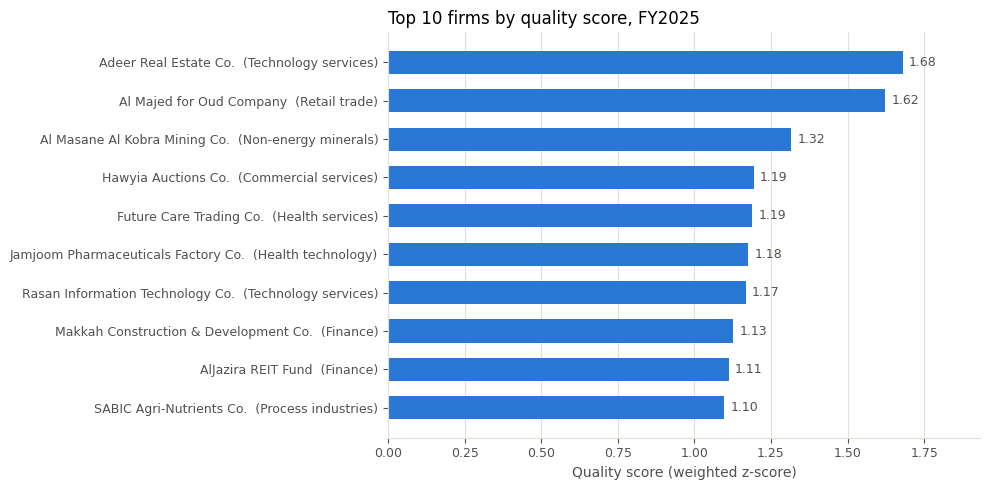

,rank,profile_name,ticker,profile_sector,quality_score,percentile,roa,net_margin,revenue_growth,debt_to_assets,cash_return_on_assets
0,1.000,Adeer Real Estate Co.,9634,Technology services,1.680,100.000,0.561,0.615,0.388,0.170,0.530
1,2.000,Al Majed for Oud Company,4165,Retail trade,1.623,99.726,0.240,0.197,0.192,0.355,0.484
2,3.000,Al Masane Al Kobra Mining Co.,1322,Non-energy minerals,1.316,99.452,0.181,0.273,0.314,0.144,0.304
3,4.000,Hawyia Auctions Co.,9641,Commercial services,1.193,99.178,0.419,0.348,0.296,0.179,0.325
4,5.000,Future Care Trading Co.,9544,Health services,1.190,98.904,0.142,0.207,0.418,0.124,0.113
5,6.000,Jamjoom Pharmaceuticals Factory Co.,4015,Health technology,1.176,98.630,0.227,0.309,0.138,0.161,0.199
6,7.000,Rasan Information Technology Co.,8313,Technology services,1.168,98.356,0.183,0.378,0.823,0.477,0.247
7,8.000,Makkah Construction & Development Co.,4100,Finance,1.127,98.082,0.110,0.442,0.283,0.112,0.095
8,9.000,AlJazira REIT Fund,4331,Finance,1.113,97.808,0.081,1.036,0.092,0.030,0.059
9,10.000,SABIC Agri-Nutrients Co.,2020,Process industries,1.098,97.534,0.160,0.331,0.182,0.174,0.196


In [11]:
leaderboard = ranked[ranked["fiscal_year"] == LAST_YEAR].sort_values("rank")
top10 = leaderboard.head(10)

fig, ax = plt.subplots(figsize=(10, 5))
labels = top10["profile_name"].str.slice(0, 38) + "  (" + top10["profile_sector"] + ")"
ax.barh(labels[::-1], top10["quality_score"][::-1], color=BLUE, height=0.6)
for y, v in enumerate(top10["quality_score"][::-1]):
    ax.text(v + 0.02, y, f"{v:.2f}", va="center", fontsize=9, color=GREY)
ax.set_xlim(0, top10["quality_score"].max() * 1.15)
ax.set_title(f"Top 10 firms by quality score, FY{LAST_YEAR}", loc="left", fontsize=12)
ax.set_xlabel("Quality score (weighted z-score)")
style_ax(ax)
plt.tight_layout()
plt.show()

top10[["rank", "profile_name", "ticker", "profile_sector", "quality_score", "percentile"] + SCORE_RATIOS].reset_index(drop=True)

In [12]:
sliders = {r: widgets.FloatSlider(value=WEIGHTS.get(r, 0.0), min=0, max=1, step=0.05, description=info["label"],
                                   style={"description_width": "160px"}, layout=widgets.Layout(width="400px"))
           for r, info in RATIO_MENU.items()}
year_box = widgets.Dropdown(options=YEARS[::-1], value=LAST_YEAR, description="Year")
sector_box = widgets.Dropdown(options=["All sectors"] + sorted(panel["profile_sector"].unique()), description="Sector")
compare_box = widgets.ToggleButtons(options=[("Sector peers", True), ("Whole market", False)], value=SECTOR_NEUTRAL, description="Compare with")
equity_box = widgets.Checkbox(value=QUALITY_GATES["negative_equity"], description="Screen out negative equity")
oneoff_box = widgets.Checkbox(value=QUALITY_GATES["one_off_profit"], description="Screen out one-off profits")

def live_screener(year, sector, sector_neutral, equity_gate, one_off_gate, **weights):
    total = sum(weights.values())
    if total == 0:
        print("Move at least one slider above 0.")
        return
    gates = {"negative_equity": equity_gate, "one_off_profit": one_off_gate}
    live = rank_firms(panel[panel["fiscal_year"] == year], weights, sector_neutral, gates)
    if sector != "All sectors":
        live = live[live["profile_sector"] == sector]
    top = live.sort_values("rank").head(10)
    in_use = [r for r, w in weights.items() if w > 0]

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.barh(top["profile_name"].str.slice(0, 38)[::-1], top["quality_score"][::-1], color=BLUE, height=0.6)
    for y, (v, rk) in enumerate(zip(top["quality_score"][::-1], top["rank"][::-1])):
        ax.text(max(v, 0) + 0.02, y, f"#{int(rk)}  {v:.2f}", va="center", fontsize=9, color=GREY)
    ax.set_xlim(min(0, top["quality_score"].min()), max(top["quality_score"].max(), 0.1) * 1.25)
    mix = " / ".join(f"{RATIO_MENU[r]['label']} {weights[r] / total:.0%}" for r in in_use)
    ax.set_title(f"Top 10, FY{year}{'' if sector == 'All sectors' else ' — ' + sector}\n{mix}", loc="left", fontsize=10)
    style_ax(ax)
    plt.tight_layout()
    plt.show()
    display(top[["rank", "profile_name", "ticker", "profile_sector", "quality_score", "percentile"] + in_use].reset_index(drop=True))

screen_out = widgets.interactive_output(live_screener, {"year": year_box, "sector": sector_box, "sector_neutral": compare_box,
                                                        "equity_gate": equity_box, "one_off_gate": oneoff_box, **sliders})
slider_grid = widgets.GridBox(list(sliders.values()), layout=widgets.Layout(grid_template_columns="repeat(2, 410px)"))
display(widgets.HBox([year_box, sector_box]), compare_box, widgets.HBox([equity_box, oneoff_box]), slider_grid, screen_out)

ToggleButtons(description='Compare with', options=(('Sector peers', True), ('Whole market', False)), value=Tru…

GridBox(children=(FloatSlider(value=0.2, description='ROA', layout=Layout(width='400px'), max=1.0, step=0.05, …

Output()

In [13]:
firm_options = sorted({(f"{n} ({t})", t) for n, t in zip(ranked["profile_name"], ranked["ticker"])})
firm_box = widgets.Dropdown(options=firm_options, value=3030, description="Firm", layout=widgets.Layout(width="520px"))

def firm_explorer(ticker):
    hist = ranked[(ranked["ticker"] == ticker) & ranked["rank"].notna()].sort_values("fiscal_year")
    if hist.empty:
        print("No ranked years for this firm.")
        return
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(hist["fiscal_year"], hist["percentile"], marker="o", color=BLUE, linewidth=2, markersize=6)
    for _, r in hist.iterrows():
        ax.annotate(f"#{int(r['rank'])}", (r["fiscal_year"], r["percentile"]), textcoords="offset points",
                    xytext=(0, 8), ha="center", fontsize=8, color=GREY)
    ax.set_ylim(0, 110)
    ax.set_xticks(hist["fiscal_year"])
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylabel("Percentile within year (100 = best)")
    ax.set_title(f"{hist['profile_name'].iloc[-1]} — percentile by year (labels show the rank)", loc="left", fontsize=12)
    style_ax(ax, grid="y")
    plt.tight_layout()
    plt.show()
    display(hist[["fiscal_year", "rank", "firms_ranked", "percentile", "quality_score"] + SCORE_RATIOS].reset_index(drop=True))

display(firm_box, widgets.interactive_output(firm_explorer, {"ticker": firm_box}))

Dropdown(description='Firm', index=299, layout=Layout(width='520px'), options=(('ACWA Power (2082)', 2082), ('…

Output()

In [14]:
top15 = leaderboard.head(15)
history = (ranked[ranked["ticker"].isin(top15["ticker"]) & (ranked["fiscal_year"] >= LAST_YEAR - 9)]
           .pivot_table(index="profile_name", columns="fiscal_year", values="rank")
           .reindex(top15["profile_name"]))
history.columns = [int(c) for c in history.columns]
history.style.background_gradient(cmap="Blues_r", axis=None).format("{:.0f}", na_rep="").set_caption(f"Rank by year — FY{LAST_YEAR} top 15")

,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
profile_name,,,,,,,,,,
Adeer Real Estate Co.,,,,,,,,,2,1
Al Majed for Oud Company,,,,,,,,30,5,2
Al Masane Al Kobra Mining Co.,,,,,107,6,74,123,17,3
Hawyia Auctions Co.,,,,,,,,,10,4
Future Care Trading Co.,,,,,,4,234,3,136,5
Jamjoom Pharmaceuticals Factory Co.,,,,,18,43,38,18,9,6
Rasan Information Technology Co.,,,,,,,,144,93,7
Makkah Construction & Development Co.,30,18,27,32,182,111,13,2,29,8
AlJazira REIT Fund,,,9,65,188,29,26,28,60,9


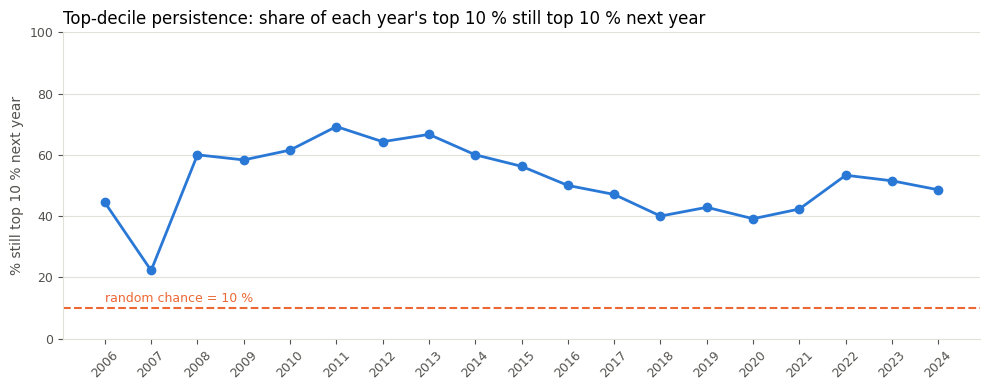

Average persistence: 51 % (chance = 10 %) | percentile correlation: 0.64
2010-2016 average: 61 %  |  2019-2024 average: 46 %


In [15]:
scored = ranked[ranked["rank"].notna()].copy()
scored["top_decile"] = scored["percentile"] >= 90

next_year = scored[["ticker", "fiscal_year", "top_decile", "percentile"]].copy()
next_year["fiscal_year"] -= 1
pairs = scored.merge(next_year, on=["ticker", "fiscal_year"], suffixes=("", "_next"))
persistence = pairs[pairs["top_decile"]].groupby("fiscal_year")["top_decile_next"].mean() * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(persistence.index, persistence.values, marker="o", color=BLUE, linewidth=2, markersize=6)
ax.axhline(10, color=ORANGE, linestyle="--", linewidth=1.5)
ax.text(persistence.index[0], 12, "random chance = 10 %", color=ORANGE, fontsize=9)
ax.set_xticks(persistence.index)
ax.tick_params(axis="x", rotation=45)
ax.set_ylim(0, 100)
ax.set_ylabel("% still top 10 % next year")
ax.set_title("Top-decile persistence: share of each year's top 10 % still top 10 % next year", loc="left", fontsize=12)
style_ax(ax, grid="y")
plt.tight_layout()
plt.show()

print(f"Average persistence: {persistence.mean():.0f} % (chance = 10 %) | percentile correlation: {pairs['percentile'].corr(pairs['percentile_next']):.2f}")
print(f"2010-2016 average: {persistence.loc[2010:2016].mean():.0f} %  |  2019-{LAST_YEAR - 1} average: {persistence.loc[2019:].mean():.0f} %")

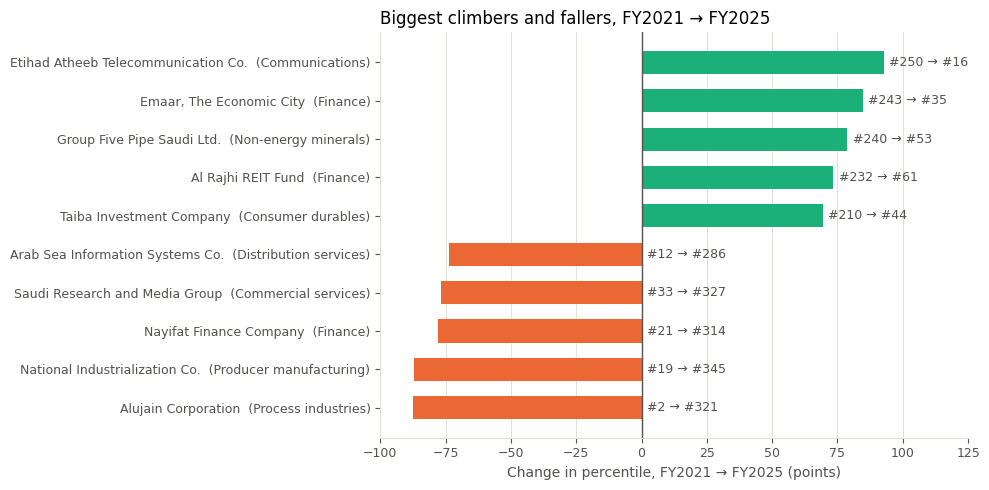

,profile_name,profile_sector,rank_start,rank_end,change
0,Etihad Atheeb Telecommunication Co.,Communications,250.000,16.000,92.778
1,"Emaar, The Economic City",Finance,243.000,35.000,84.848
2,Group Five Pipe Saudi Ltd.,Non-energy minerals,240.000,53.000,78.750
3,Al Rajhi REIT Fund,Finance,232.000,61.000,73.445
4,Taiba Investment Company,Consumer durables,210.000,44.000,69.542
5,Arab Sea Information Systems Co.,Distribution services,12.000,286.000,-73.802
6,Saudi Research and Media Group,Commercial services,33.000,327.000,-76.864
7,Nayifat Finance Company,Finance,21.000,314.000,-77.971
8,National Industrialization Co.,Producer manufacturing,19.000,345.000,-87.243
9,Alujain Corporation,Process industries,2.000,321.000,-87.282


In [16]:
START = 2021
a = scored[scored["fiscal_year"] == START][["ticker", "profile_name", "profile_sector", "rank", "percentile"]]
b = scored[scored["fiscal_year"] == LAST_YEAR][["ticker", "rank", "percentile"]]
movers = a.merge(b, on="ticker", suffixes=("_start", "_end"))
movers["change"] = movers["percentile_end"] - movers["percentile_start"]
show = pd.concat([movers.nlargest(5, "change"), movers.nsmallest(5, "change")]).sort_values("change")

fig, ax = plt.subplots(figsize=(10, 5))
labels = show["profile_name"].str.slice(0, 36) + "  (" + show["profile_sector"] + ")"
ax.barh(labels, show["change"], color=[AQUA if v > 0 else ORANGE for v in show["change"]], height=0.6)
for y, (v, r0, r1) in enumerate(zip(show["change"], show["rank_start"], show["rank_end"])):
    ax.text(v + 2 if v > 0 else 2, y, f"#{int(r0)} → #{int(r1)}", va="center", fontsize=9, color=GREY)
ax.axvline(0, color=GREY, linewidth=1)
ax.set_xlim(-100, 125)
ax.set_xlabel(f"Change in percentile, FY{START} → FY{LAST_YEAR} (points)")
ax.set_title(f"Biggest climbers and fallers, FY{START} → FY{LAST_YEAR}", loc="left", fontsize=12)
style_ax(ax)
plt.tight_layout()
plt.show()

show[["profile_name", "profile_sector", "rank_start", "rank_end", "change"]].sort_values("change", ascending=False).reset_index(drop=True)

In [17]:
# Main Market vs Nomu (Nomu tickers are 9500-9699)
ranked["market"] = np.where(ranked["ticker"].between(9500, 9699), "Nomu", "Main Market")
latest = ranked[(ranked["fiscal_year"] == LAST_YEAR) & ranked["rank"].notna()]

share = pd.DataFrame({
    "All ranked firms (%)": latest["market"].value_counts(normalize=True) * 100,
    "Top 50 (%)": latest[latest["rank"] <= 50]["market"].value_counts(normalize=True) * 100,
    "Top 10 (%)": latest[latest["rank"] <= 10]["market"].value_counts(normalize=True) * 100,
}).fillna(0).round(0)
display(share)

main = latest[latest["market"] == "Main Market"].sort_values("rank").head(10).copy()
main.insert(0, "main_market_rank", range(1, len(main) + 1))
main[["main_market_rank", "rank", "profile_name", "ticker", "profile_sector", "quality_score"]].reset_index(drop=True)

,All ranked firms (%),Top 50 (%),Top 10 (%)
market,,,
Main Market,69.000,60.000,70.000
Nomu,31.000,40.000,30.000


,main_market_rank,rank,profile_name,ticker,profile_sector,quality_score
0,1,2.000,Al Majed for Oud Company,4165,Retail trade,1.623
1,2,3.000,Al Masane Al Kobra Mining Co.,1322,Non-energy minerals,1.316
2,3,6.000,Jamjoom Pharmaceuticals Factory Co.,4015,Health technology,1.176
3,4,7.000,Rasan Information Technology Co.,8313,Technology services,1.168
4,5,8.000,Makkah Construction & Development Co.,4100,Finance,1.127
5,6,9.000,AlJazira REIT Fund,4331,Finance,1.113
6,7,10.000,SABIC Agri-Nutrients Co.,2020,Process industries,1.098
7,8,11.000,SAL Saudi Logistics Services Company,4263,Transportation,1.070
8,9,12.000,Arriyadh Development Co.,4150,Finance,1.068
9,10,15.000,Umm Al Qura for Development and Construction C...,4325,Finance,0.961


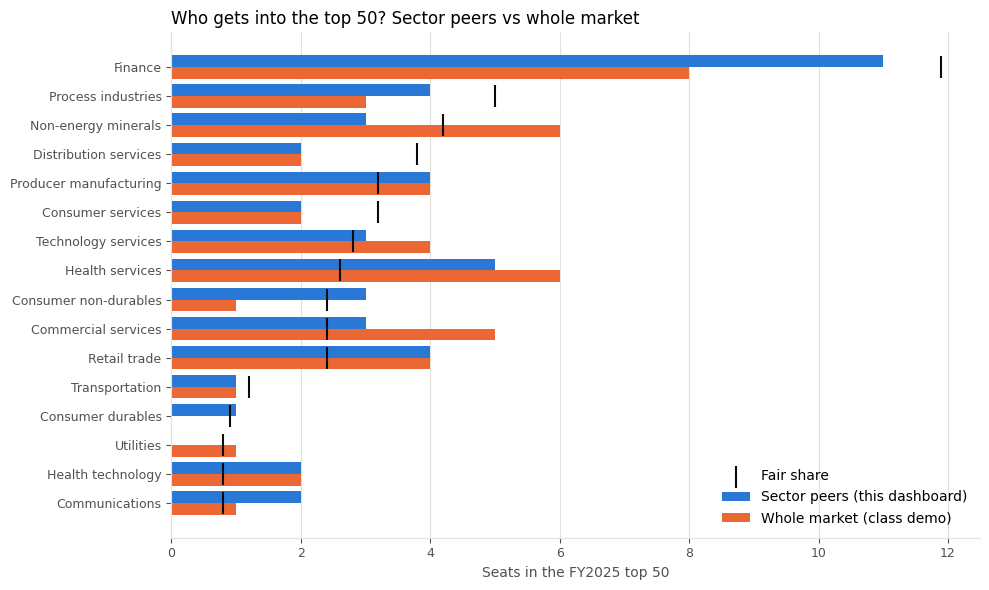

Median ROA FY2025 -- Finance: 1.8% | other sectors: 5.4%


,Sector peers (this dashboard),Whole market (class demo),Fair share (50 x % of firms)
profile_sector,,,
Finance,11,8,11.900
Process industries,4,3,5.000
Non-energy minerals,3,6,4.200
Distribution services,2,2,3.800
Producer manufacturing,4,4,3.200
Consumer services,2,2,3.200
Technology services,3,4,2.800
Health services,5,6,2.600
Consumer non-durables,3,1,2.400


In [18]:
market_ranked = rank_firms(panel, WEIGHTS, sector_neutral=False)
latest_sector = ranked[ranked["fiscal_year"] == LAST_YEAR]
latest_market = market_ranked[market_ranked["fiscal_year"] == LAST_YEAR]

seats = pd.DataFrame({
    "Sector peers (this dashboard)": latest_sector[latest_sector["rank"] <= 50]["profile_sector"].value_counts(),
    "Whole market (class demo)": latest_market[latest_market["rank"] <= 50]["profile_sector"].value_counts(),
}).fillna(0).astype(int)
seats["Fair share (50 x % of firms)"] = (50 * latest_sector["profile_sector"].value_counts(normalize=True)).round(1)
seats = seats.fillna(0).sort_values("Fair share (50 x % of firms)")

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(seats))
ax.barh(y + 0.2, seats["Sector peers (this dashboard)"], height=0.4, color=BLUE, label="Sector peers (this dashboard)")
ax.barh(y - 0.2, seats["Whole market (class demo)"], height=0.4, color=ORANGE, label="Whole market (class demo)")
ax.scatter(seats["Fair share (50 x % of firms)"], y, marker="|", s=250, color="#0b0b0b", label="Fair share", zorder=3)
ax.set_yticks(y)
ax.set_yticklabels(seats.index)
ax.set_xlabel(f"Seats in the FY{LAST_YEAR} top 50")
ax.set_title("Who gets into the top 50? Sector peers vs whole market", loc="left", fontsize=12)
ax.legend(frameon=False, loc="lower right")
style_ax(ax)
plt.tight_layout()
plt.show()

fin = latest_sector["profile_sector"] == "Finance"
print(f"Median ROA FY{LAST_YEAR} -- Finance: {latest_sector.loc[fin, 'roa'].median():.1%} | other sectors: {latest_sector.loc[~fin, 'roa'].median():.1%}")
seats.sort_values("Fair share (50 x % of firms)", ascending=False)

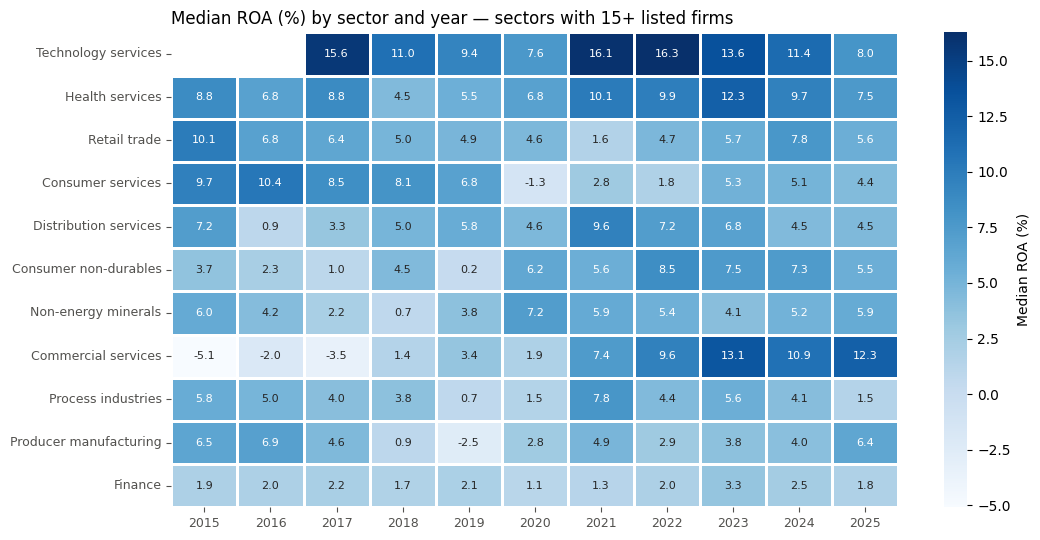

In [19]:
big = panel[panel["fiscal_year"] == LAST_YEAR]["profile_sector"].value_counts()
big = big[big >= 15].index
heat = (panel[panel["profile_sector"].isin(big) & (panel["fiscal_year"] >= LAST_YEAR - 10)]
        .groupby(["profile_sector", "fiscal_year"])["roa"].median().unstack() * 100)
heat = heat.loc[heat.mean(axis=1).sort_values(ascending=False).index]
heat.columns = [int(c) for c in heat.columns]

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.heatmap(heat, annot=True, fmt=".1f", cmap="Blues", linewidths=1, linecolor="white",
            cbar_kws={"label": "Median ROA (%)"}, annot_kws={"size": 8}, ax=ax)
ax.set_title("Median ROA (%) by sector and year — sectors with 15+ listed firms", loc="left", fontsize=12)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(colors=GREY, labelsize=9)
plt.tight_layout()
plt.show()

In [20]:
cols = ["profile_name", "revenue", "operating_income", "net_income", "cash_from_operating_activities", "bs_total_equity"]
check = (raw[raw["ticker"].isin([2110, 2140]) & (raw["fiscal_year"] == LAST_YEAR)][["ticker"] + cols]
         .merge(ranked.loc[ranked["fiscal_year"] == LAST_YEAR, ["ticker", "status"]], on="ticker")
         .drop(columns="ticker").set_index("profile_name"))
money = cols[1:]
check[money] = (check[money] / 1e6).round(1)
print(f"Class screener's top two for FY{LAST_YEAR} (SAR millions):")
display(check)

screened = ranked[(ranked["fiscal_year"] == LAST_YEAR) & ranked["status"].str.startswith("screened")]
print(f"All firms screened out in FY{LAST_YEAR}:", len(screened))
screened[["profile_name", "profile_sector", "status"]].reset_index(drop=True)

Class screener's top two for FY2025 (SAR millions):


,revenue,operating_income,net_income,cash_from_operating_activities,bs_total_equity,status
profile_name,,,,,,
Saudi Cable Co.,156.000,-97.700,201.900,-94.900,-214.400,screened out: negative equity
AYYAN Investment Company,8.700,-21.900,359.700,-237.700,952.300,screened out: one off profit


All firms screened out in FY2025: 10


,profile_name,profile_sector,status
0,Saudi Cable Co.,Producer manufacturing,screened out: negative equity
1,AYYAN Investment Company,Industrial services,screened out: one off profit
2,National Co. for Glass Industries,Process industries,screened out: one off profit
3,ARTEX Industrial Investment Company,Consumer durables,screened out: one off profit
4,Morabaha Marina Financing Company,Finance,screened out: one off profit
5,Fitaihi Holding Group,Distribution services,screened out: one off profit
6,AFG International Company,Retail trade,screened out: negative equity
7,Al Gassim Investment Holding Co.,Process industries,screened out: one off profit
8,Knowledge Net Company,Technology services,screened out: one off profit
9,Mayar Holding Co.,Producer manufacturing,screened out: negative equity


In [ ]:
def clean(values, digits):
    return [None if pd.isna(v) else round(float(v), digits) for v in values]

payload = {
    "title": "Tadawul Firm Ranking Dashboard — Quality & Resilience Screen",
    "subtitle": "Every Tadawul-listed firm scored and ranked within every fiscal year. Move any ratio's weight and the whole ranking recomputes in your browser.",
    "source": "tadawul_merged.csv (Tadawul-listed firms, FY2006-FY2026)",
    "generated": datetime.date.today().isoformat(),
    "years": YEARS,
    "filings": {int(y): int(n) for y, n in panel.groupby("fiscal_year")["ticker"].count().items()},
    "default_firm": 3030,
    "settings": {"sector_neutral": SECTOR_NEUTRAL, "min_weight_reported": MIN_WEIGHT_REPORTED},
    "ratios": [{"key": r, **info, "weight": float(WEIGHTS.get(r, 0))} for r, info in RATIO_MENU.items()],
    "gates": [{"key": g, "label": "Screen out " + g.replace("_", " ").replace("one off", "one-off"), "on": bool(on)}
              for g, on in QUALITY_GATES.items()],
    "firms": [[int(r["ticker"]), str(r["profile_name"]), str(r["profile_sector"]), int(r["fiscal_year"]),
               clean([r[c] for c in RATIOS], 4),
               clean([r[c + "_zs"] for c in RATIOS], 3),
               clean([r[c + "_zm"] for c in RATIOS], 3),
               [int(r["fails_" + g]) for g in QUALITY_GATES]]
              for _, r in panel.iterrows()],
}

with open("dashboard_data.json", "w", encoding="utf-8") as f:
    json.dump(payload, f, ensure_ascii=False, allow_nan=False, separators=(",", ":"))

print("Saved dashboard_data.json:", len(payload["firms"]), "firm-years,", len(RATIOS), "ratios")
files.download("dashboard_data.json")